# NetFlow Autoencoder Outlier Detection Lab (Unsupervised)

This notebook shows a practical unsupervised workflow: **use an autoencoder to detect outliers** in NetFlow/IPFIX-style flow records.

## Objectives
- Build a **baseline** dataset that represents “typical” traffic (no labels used for training).
- Create a second flow file with **injected synthetic outliers** that the baseline model should not reconstruct well.
- Train an **autoencoder** only on baseline flows.
- Use **reconstruction error** as an anomaly score.
- Choose an outlier threshold and evaluate detection quality using the injected ground-truth outlier flag (for learning purposes).

## Why do we generate a second flow file?
In real security/operations settings, you rarely have perfect ground truth for anomalies. For a lab, however, it’s useful to create a dataset where we *know* which rows are “outliers” so we can quantify how well the approach works.

In this lab we will generate `flows_with_outliers.csv`, which contains:
- Many baseline-like flows (normal), and
- A smaller set of synthetic outliers created by perturbing flow statistics beyond the typical ranges.

Important note: these injected outliers are **not a model of real attacks**. They are just examples of “unusual flow statistics” to demonstrate the technique.

In [14]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
# Optional plotting (the notebook still runs if matplotlib is unavailable)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception as e:
    HAS_MPL = False
    print('Matplotlib not available, skipping plots:', e)

# Optional rich display (works in Jupyter; we fall back to print if missing)
try:
    from IPython.display import display
except Exception:
    display = None

In [16]:
# Load the original flow dataset
df = pd.read_csv('flows.csv')
df.head(10)

,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt,Label
0,25405,443,17,7708.731622,379.0,94.0,210724.0,50384.0,33871.720121,61.358992,0,0,0,VPN
1,55432,8080,6,3024.530486,122.0,1098.0,27084.0,976122.0,331689.829065,403.368392,1,7,1,VIDEO
2,56850,443,6,5081.732696,89.0,44.0,56782.0,34848.0,18031.251441,26.172176,2,6,0,BULK
3,49672,5061,17,5859.682646,308.0,119.0,19404.0,13209.0,5565.659776,72.870841,0,0,0,VOIP
4,50499,443,6,4686.218441,44.0,76.0,16940.0,70072.0,18567.636378,25.607001,1,5,1,WEB
5,33357,443,6,8476.412156,114.0,34.0,126540.0,26894.0,18101.290639,17.460218,2,1,1,BULK
6,15748,443,6,3062.836794,266.0,391.0,139118.0,143106.0,92144.642045,214.507022,0,6,0,VPN
7,39782,443,6,3693.393050,116.0,88.0,30160.0,37840.0,18411.254657,55.233764,2,7,0,VPN
8,64991,443,17,2495.019157,34.0,53.0,2346.0,46163.0,19442.335691,34.869472,0,0,0,WEB
9,48358,1935,6,4272.714279,45.0,637.0,4545.0,348439.0,82613.527832,159.617507,2,5,0,VIDEO


## Step 1 — Build a baseline dataset (no outliers)

To make outlier detection meaningful, the autoencoder should be trained on data that represents “normal” patterns.

In real life, defining “normal” is hard and depends on context. In a lab, a common approach is to remove extreme values using robust quantiles.

We will:
- Remove the `Label` column from training features (if present).
- Define a set of numeric columns that typically have heavy tails (bytes/packets/duration/rates).
- Keep only rows whose values for those columns fall between the 1st and 99th percentile (configurable).

This gives us a baseline subset that is less likely to contain extreme flows.

In [17]:
has_label = 'Label' in df.columns
X_raw = df.drop(columns=['Label']) if has_label else df.copy()

# Columns that tend to capture volume/timing extremes (use the intersection of what exists)
candidate_cols = [
    'FlowDurationMs',
    'TotFwdPkts',
    'TotBwdPkts',
    'TotLenFwdBytes',
    'TotLenBwdBytes',
    'FlowBytsPerS',
    'FlowPktsPerS',
]
robust_cols = [c for c in candidate_cols if c in X_raw.columns]

q_low, q_high = 0.01, 0.99
mask = np.ones(len(X_raw), dtype=bool)
for c in robust_cols:
    lo = X_raw[c].quantile(q_low)
    hi = X_raw[c].quantile(q_high)
    mask &= X_raw[c].between(lo, hi)

df_baseline = df.loc[mask].copy()
print('Original rows:', len(df))
print('Baseline rows after quantile filter:', len(df_baseline))
robust_cols

Original rows: 50000
Baseline rows after quantile filter: 44889


['FlowDurationMs',
 'TotFwdPkts',
 'TotBwdPkts',
 'TotLenFwdBytes',
 'TotLenBwdBytes',
 'FlowBytsPerS',
 'FlowPktsPerS']

## Step 2 — Generate a second flow file with injected outliers

We will create a synthetic dataset `flows_with_outliers.csv` by:
- sampling many baseline-like flows, and
- creating outliers by copying baseline flows and perturbing key numeric fields (bytes/packets/rates/duration/ports).

We also add a boolean column `IsInjectedOutlier` so we can evaluate detection quality in this lab. This column is **not** used for training.

Tip: keep the outlier fraction small (e.g., 1–5%). This matches many practical anomaly detection situations where outliers are rare.

In [18]:
rng = np.random.default_rng(42)

# How much data to use for this lab (keeps runtime reasonable)
n_normal = 15000
n_outliers = 500

df_normal = df_baseline.sample(n=min(n_normal, len(df_baseline)), random_state=42).copy()
df_normal['IsInjectedOutlier'] = False

df_out = df_baseline.sample(n=min(n_outliers, len(df_baseline)), random_state=123).copy()
df_out['IsInjectedOutlier'] = True

# Perturb numeric columns to create unusually large/odd flows
def multiply_if_present(frame: pd.DataFrame, col: str, factor: float):
    if col in frame.columns:
        frame[col] = np.maximum(0, frame[col].to_numpy() * factor)

# Make volume and rates much larger than baseline
multiply_if_present(df_out, 'TotLenFwdBytes', 50.0)
multiply_if_present(df_out, 'TotLenBwdBytes', 50.0)
multiply_if_present(df_out, 'TotFwdPkts', 20.0)
multiply_if_present(df_out, 'TotBwdPkts', 20.0)
multiply_if_present(df_out, 'FlowBytsPerS', 30.0)
multiply_if_present(df_out, 'FlowPktsPerS', 30.0)
multiply_if_present(df_out, 'FlowDurationMs', 10.0)

# Set ports/protocol to unusual values (if present)
unusual_ports = np.array([0, 1, 7, 9, 19, 12345, 31337, 65535], dtype=float)
if 'DstPort' in df_out.columns:
    df_out['DstPort'] = rng.choice(unusual_ports, size=len(df_out))
if 'SrcPort' in df_out.columns:
    df_out['SrcPort'] = rng.choice(unusual_ports, size=len(df_out))
if 'Protocol' in df_out.columns:
    df_out['Protocol'] = 255

df_with_outliers = pd.concat([df_normal, df_out], ignore_index=True)
df_with_outliers = df_with_outliers.sample(frac=1.0, random_state=7).reset_index(drop=True)

out_path = 'flows_with_outliers.csv'
df_with_outliers.to_csv(out_path, index=False)
print('Wrote', out_path, 'rows=', len(df_with_outliers))
df_with_outliers.head()

Wrote flows_with_outliers.csv rows= 15500


,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt,Label,IsInjectedOutlier
0,56319.0,500.0,6,2253.359881,249.0,45.0,46563.0,23490.0,31088.243196,130.471836,0,1,1,VPN,False
1,44172.0,443.0,6,2658.144046,53.0,17.0,8427.0,14059.0,8459.285732,26.334164,2,8,1,WEB,False
2,2328.0,443.0,6,1095.673440,11.0,79.0,3388.0,40843.0,40368.779956,82.141263,2,4,1,WEB,False
3,25708.0,443.0,6,7028.772331,59.0,47.0,10207.0,16591.0,3812.614599,15.080870,1,2,1,WEB,False
4,43103.0,1935.0,17,7578.610678,108.0,1173.0,28404.0,1124907.0,152179.739655,169.028342,0,0,0,VIDEO,False


## Step 3 — Preprocess and train the autoencoder on baseline only

Key principle: **do not train on the outliers** you want to detect.

We will:
- Fit preprocessing (imputer + scaler + one-hot) on baseline data.
- Transform baseline and train an autoencoder to reconstruct it.
- Transform the mixed evaluation set (normal + injected outliers) using the same preprocessing.
- Compute reconstruction error for each row as an anomaly score.

In [19]:
df_mix = pd.read_csv('flows_with_outliers.csv')

# Split baseline vs evaluation (outliers are for evaluation, not training)
df_train = df_mix[df_mix['IsInjectedOutlier'] == False].copy()
df_eval = df_mix.copy()

# Remove label from inputs if present
X_train_raw = df_train.drop(columns=['Label'], errors='ignore').drop(columns=['IsInjectedOutlier'])
X_eval_raw = df_eval.drop(columns=['Label'], errors='ignore').drop(columns=['IsInjectedOutlier'])

numeric_features = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_raw.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot),
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

X_train = preprocess.fit_transform(X_train_raw)
X_eval = preprocess.transform(X_eval_raw)

print('Train shape:', X_train.shape)
print('Eval shape:', X_eval.shape)

Train shape: (15000, 13)
Eval shape: (15500, 13)


In [20]:
autoencoder = MLPRegressor(
    hidden_layer_sizes=(64, 16, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42,
    verbose=False,
 )

autoencoder.fit(X_train, X_train)
X_train_hat = autoencoder.predict(X_train)
X_eval_hat = autoencoder.predict(X_eval)

train_mse = np.mean((X_train - X_train_hat) ** 2, axis=1)
eval_mse = np.mean((X_eval - X_eval_hat) ** 2, axis=1)

print('Train recon MSE summary:')
print(pd.Series(train_mse).describe())
print('\nEval recon MSE summary:')
print(pd.Series(eval_mse).describe())

Train recon MSE summary:
count    15000.000000
mean         0.000481
std          0.000492
min          0.000018
25%          0.000202
50%          0.000342
75%          0.000594
max          0.012599
dtype: float64

Eval recon MSE summary:
count    15500.000000
mean         0.660557
std          4.552361
min          0.000018
25%          0.000206
50%          0.000354
75%          0.000634
max        156.080037
dtype: float64


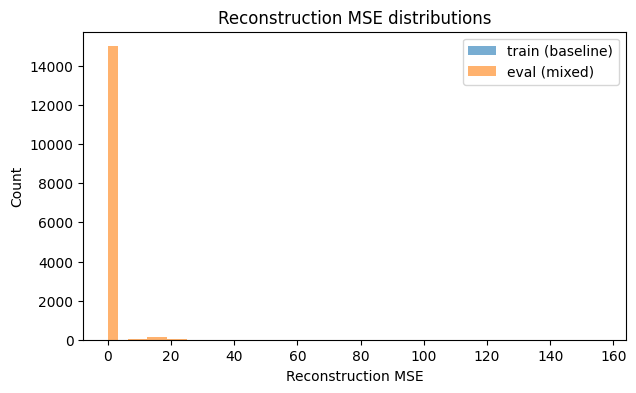

In [21]:
# Optional: visualize score distributions
if HAS_MPL:
    plt.figure(figsize=(7, 4))
    plt.hist(train_mse, bins=50, alpha=0.6, label='train (baseline)')
    plt.hist(eval_mse, bins=50, alpha=0.6, label='eval (mixed)')
    plt.title('Reconstruction MSE distributions')
    plt.xlabel('Reconstruction MSE')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
else:
    print('Matplotlib not available; skipping histogram plots.')

## Step 4 — Choose a threshold and evaluate outlier detection

We now have an anomaly score: reconstruction MSE.

A simple thresholding rule is to flag anything above a high quantile of the **training (baseline)** error distribution.
For example, a 99.5th percentile threshold means: “flag the worst 0.5% of baseline reconstruction errors.”

In the real world, choosing thresholds depends on your alert budget and investigation capacity. In this lab, we also have an injected outlier ground truth column, so we can quantify detection precision/recall.

We will compute:
- Confusion matrix (normal vs outlier)
- Precision/recall/F1 for the outlier class

In [22]:
threshold_q = 0.995
threshold = np.quantile(train_mse, threshold_q)

y_true = df_eval['IsInjectedOutlier'].astype(int).to_numpy()
y_pred = (eval_mse >= threshold).astype(int)

print(f'Threshold at q={threshold_q}: {threshold:.6f}')
print('Confusion matrix:')
print(confusion_matrix(y_true, y_pred))
print('\nClassification report (0=normal, 1=outlier):')
print(classification_report(y_true, y_pred, target_names=['normal', 'outlier']))

Threshold at q=0.995: 0.002936
Confusion matrix:
[[14925    75]
 [    0   500]]

Classification report (0=normal, 1=outlier):
              precision    recall  f1-score   support

      normal       1.00      0.99      1.00     15000
     outlier       0.87      1.00      0.93       500

    accuracy                           1.00     15500
   macro avg       0.93      1.00      0.96     15500
weighted avg       1.00      1.00      1.00     15500



In [23]:
# Inspect the top flagged rows
df_eval_scored = df_eval.copy()
df_eval_scored['recon_mse'] = eval_mse
df_eval_scored['pred_outlier'] = y_pred.astype(bool)

top_flagged = df_eval_scored.sort_values('recon_mse', ascending=False).head(20)
(display(top_flagged) if display is not None else top_flagged)

,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt,Label,IsInjectedOutlier,recon_mse,pred_outlier
15088,12345.0,65535.0,255,101364.528859,2000.0,26880.0,425000.0,76540800.0,4.555783e+06,4273.684344,2,6,0,VIDEO,True,156.080037,True
14699,9.0,1.0,255,73432.046144,2580.0,24500.0,941700.0,75582500.0,6.252654e+06,5531.644852,0,0,0,VIDEO,True,128.831931,True
6797,31337.0,12345.0,255,130190.652253,3200.0,19200.0,712000.0,66624000.0,3.103264e+06,2580.830453,0,0,0,VIDEO,True,124.232723,True
2174,1.0,7.0,255,59457.423619,3640.0,27640.0,2711800.0,78290300.0,8.174128e+06,7891.361103,0,7,0,VIDEO,True,100.073401,True
12542,65535.0,65535.0,255,53959.332501,2080.0,26220.0,535600.0,74858100.0,8.383391e+06,7867.035790,2,6,1,VIDEO,True,97.879055,True
4750,0.0,7.0,255,43890.061230,2960.0,2160.0,10478400.0,6485400.0,2.319040e+06,1749.826677,2,4,1,BULK,True,82.114569,True
1084,1.0,12345.0,255,52024.100147,3220.0,1960.0,10456950.0,6159300.0,1.916371e+06,1493.538567,1,8,1,BULK,True,80.923482,True
11153,1.0,12345.0,255,60242.110452,3860.0,18980.0,1553650.0,63962600.0,6.525294e+06,5687.051755,0,0,0,VIDEO,True,74.766065,True
5882,0.0,12345.0,255,88623.992330,2340.0,20060.0,1444950.0,57321450.0,3.978589e+06,3791.298396,2,2,1,VIDEO,True,72.336757,True
14301,1.0,12345.0,255,69226.859722,2320.0,24260.0,1699400.0,63318600.0,5.635212e+06,5759.325233,0,0,0,VIDEO,True,72.207276,True


## Optional interpretation using `Label` (post-hoc only)

If your dataset contains a `Label` column, you can use it **after training** to understand what kinds of flows are being flagged.

This is not required for anomaly detection, but it is useful to answer questions like:
- Are we flagging mostly one traffic type?
- Do injected outliers concentrate in certain labels?

Remember: in a true unsupervised setting you may not have labels, so this step is purely for learning and sanity checks.

In [24]:
if 'Label' in df_eval_scored.columns:
    flagged = df_eval_scored[df_eval_scored['pred_outlier'] == True]
    print('Label distribution among flagged rows:')
    print(flagged['Label'].value_counts(normalize=True).head(10))
else:
    print('No Label column found; skipping label interpretation.')

Label distribution among flagged rows:
Label
WEB      0.339130
VIDEO    0.231304
VOIP     0.172174
VPN      0.144348
BULK     0.113043
Name: proportion, dtype: float64
